## Importing Libraries

In [1]:
# Utility
import numpy as np
import pandas as pd
import pickle
import os
import joblib

# Plotting
import seaborn as sns
from wordcloud import WordCloud
import matplotlib.pyplot as plt
%matplotlib inline

# nltk
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from string import punctuation

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
os.makedirs("./data" , exist_ok=True)

os.environ['NLTK_DATA'] = "data"

# Downloading dependencies
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/ashish-d/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/ashish-d/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /home/ashish-d/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/ashish-d/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## Data Import

In [4]:
df = pd.read_csv('cyberbullying_tweets.csv')
display(df.sample(5))
df.shape

,tweet_text,cyberbullying_type
37240,oomf looks like my middle school bully and i P...,age
31575,a kickstarter is tempting. but I'm just so wei...,other_cyberbullying
12846,@omfgmorrison BLESS. Hook's allowed to make ra...,gender
7127,@AlexJohanson3 @nathanielhadden can tell you w...,not_cyberbullying
663,Im gonna live....my life.....,not_cyberbullying


(47692, 2)

In [5]:
df['cyberbullying_type'].unique()

<ArrowStringArray>
[  'not_cyberbullying',              'gender',            'religion',
 'other_cyberbullying',                 'age',           'ethnicity']
Length: 6, dtype: str

In [6]:
for tweet in df.sample(5)['tweet_text']:
    print(tweet +'\n')

@RudawEnglish Utterly insane article.

Bullied because I was a bookworm, because I couldn't speak nor read Arabic properly and also in my teen because I was not feminine enough compared to other girls in my high-school

GamerGate is advocating that /baph stalk my son. http://t.co/S8hlFXRmzo

OMG THIS BITCH i swear i might become a school bully wtf is this. I HATE HER OMGSJSJWHSJS (i summon my personal meme)

@Abu_Baraa1 Looks more like the Daesh are getting a taste of their own medicine.



In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   tweet_text          47692 non-null  str  
 1   cyberbullying_type  47692 non-null  str  
dtypes: str(2)
memory usage: 7.4 MB


In [8]:
df.describe()

,tweet_text,cyberbullying_type
count,47692,47692
unique,46017,6
top,"@Jason_Gio meh. :P thanks for the heads up, b...",religion
freq,2,7998


## Data Pre-processing

**Looking for null and duplicate values**

In [9]:
df.isnull().sum()

tweet_text            0
cyberbullying_type    0
dtype: int64

In [10]:
df['tweet_text'].duplicated().sum()

np.int64(1675)

Dropping duplicates

In [11]:
df.drop_duplicates('tweet_text', inplace=True, ignore_index=True)
df['tweet_text'].duplicated().sum()

np.int64(0)

**Checking for balanced classes**

In [12]:
df['cyberbullying_type'].value_counts()

cyberbullying_type
religion               7995
age                    7992
ethnicity              7952
not_cyberbullying      7937
gender                 7898
other_cyberbullying    6243
Name: count, dtype: int64

In [13]:
df = df[df["cyberbullying_type"] != "other_cyberbullying"]
df['cyberbullying_type'].unique()

<ArrowStringArray>
['not_cyberbullying', 'gender', 'religion', 'age', 'ethnicity']
Length: 5, dtype: str

**Label Encoding the Classes**

In [14]:
cyberbullying_type = ['not_cyberbullying', 'gender', 'religion', 'age', 'ethnicity']
encoding_dict = {'not_cyberbullying':0, 'gender':1, 'religion':2, 'age':3, 'ethnicity':4}
df['cyberbullying_type'] = df['cyberbullying_type'].map(encoding_dict)
df.sample(5)

,tweet_text,cyberbullying_type
16409,There are people suffering there. There is a g...,2
14528,@ChrisWarcraft So you're saying jokes about ch...,1
20979,So you don't have an answer for why muslims ha...,2
4471,"@alanpdx yeah, i've got around ~1k books.",0
36464,"what was I not bullied for? My weight, my glas...",3


## NLP Processing

Cleaning the tweets and then processing them to a new column

In [15]:
stopwords_list = stopwords.words('english')
additional_stopwords = ['rt', 'mkr', 'didn', 'bc', 'n', 'm', 'im', 'll', 'y', 've', 'u', 'ur', 'don', 't', 's']   # Specific to twitter lingo
stopwords_list.extend(additional_stopwords)
lemmatizer = WordNetLemmatizer()    # Using Lemmatizer instead of Stemmer

Custom defined functions to deep clean the unprocessed tweets


In [16]:
def remove_usernames(tweet):
    words = tweet.strip().split()
    words = [word for word in words if word[0]!='@']
    return ' '.join(words)

def remove_hashtags(tweet):
    words = tweet.strip().split()
    words = [word for word in words if word[0]!='#']
    return ' '.join(words)

def remove_links(tweet):
    words = tweet.strip().split()
    words = [word for word in words if word[:4]!='http']
    return ' '.join(words) 

def remove_punctuation(tweet):
    for mark in punctuation:
        tweet = tweet.replace(mark, '')
    return tweet

def convert_lowercase(tweet):
    return tweet.lower()

def tokenization(tweet):
    return word_tokenize(tweet)

def remove_stopwords(tok_tweet):
    res = []
    for word in tok_tweet:
        if word not in stopwords_list:
            res.append(word)
    return res

def lemmatize_words(tok_tweet):
    res = []
    for word in tok_tweet:
        res.append(lemmatizer.lemmatize(word))
    return res

In [17]:
# Defining a custom tweet cleaning function
def pre_processing_custom(tweet):
    tweet = remove_usernames(tweet)
    tweet = remove_hashtags(tweet)
    tweet = remove_links(tweet)
    tweet = remove_punctuation(tweet)
    tweet = convert_lowercase(tweet)
    tok_tweet = tokenization(tweet)
    tok_tweet = remove_stopwords(tok_tweet)
    tok_tweet = lemmatize_words(tok_tweet)
    clean_tweet = ' '.join(tok_tweet)

    return clean_tweet

Applying this processing function to our dataset

In [18]:
df['clean_tweets'] = df['tweet_text'].map(pre_processing_custom)
df.sample(5)

,tweet_text,cyberbullying_type,clean_tweets
20957,"As bad as he is,we got Radical Evangelical Chr...",2,bad iswe got radical evangelical christian mak...
6288,I love little kid 'foodies'. #mkr,0,love little kid foodie
18630,So many lies about Hillary. They have really d...,2,many lie hillary really done number knew godfe...
17772,So what r u if we r bhakts? Touts? Do some sel...,2,r r bhakts tout self realization see around ma...
10787,@MaddyBaylor Hey @BristolBen please translate ...,1,hey please translate nonsensical nonanswer canty


In [19]:
%pip install tweet-preprocessor
import preprocessor as p

Note: you may need to restart the kernel to use updated packages.


In [20]:
def clean_tweets(tweet):
    tweet = p.clean(tweet)
    return tweet

In [21]:
# Defining the better cleaning function
def pre_processing(tweet):
    tweet = clean_tweets(tweet)
    tweet = remove_punctuation(tweet)
    tweet = convert_lowercase(tweet)
    tok_tweet = tokenization(tweet)
    tok_tweet = remove_stopwords(tok_tweet)
    tok_tweet = lemmatize_words(tok_tweet)
    clean_tweet = ' '.join(tok_tweet)

    return clean_tweet

In [22]:
# Clean tweets
df['clean_tweets'] = df['tweet_text'].map(pre_processing)
df.sample(5)

,tweet_text,cyberbullying_type,clean_tweets
4919,@kburgess33 I mean if I can't rank oppressions...,0,mean cant rank oppression going know shouldnt ...
12408,"@Jilltweety OMG Darryn has to go, I feel ill e...",1,omg darryn go feel ill everytime expose gross ...
13711,Was it a gay joke or submissive joke? Sex acts...,1,gay joke submissive joke sex act often power a...
5660,Maybe I'm reading this document wrong. http://...,0,maybe reading document wrong
4766,Why is Colon being so nice? WHY? #MKR,0,colon nice


Checking again for duplicate values

In [23]:
df['clean_tweets'].duplicated().sum()

np.int64(1215)

Removing them

In [24]:
df.drop_duplicates('clean_tweets', inplace=True, ignore_index=True)
df['clean_tweets'].duplicated().sum()

np.int64(0)

In [25]:
df.shape

(38559, 3)

**38557** tweets are remaining

Calculating the total and average word lengths of each tweet

In [26]:
# Total word count of a tweet
df['word_count'] = df['tweet_text'].map(lambda x: len(x.split()))
df.sample(5)

,tweet_text,cyberbullying_type,clean_tweets,word_count
16119,SEEKING devision from those that are DEMANDING...,2,seeking devision demanding black racial superi...,35
30402,Did they though? How many kids killing themsel...,3,though many kid killing bully many kid shootin...,24
8237,@JustAnotherMo awww but I don't make gay rape ...,1,awww dont make gay rape joke mo swear ever see...,28
13319,@SxFlint93 Oh I do plenty but picking rotten l...,1,oh plenty picking rotten low hanging sexist fr...,20
2834,"@XuetaoShi @simon_lindsell no, it wasn't. I'm ...",0,wasnt minority used try silence woman,20


In [27]:
# Average word length of a tweet
def avg_word_length(tweet):
    words = tweet.split()
    word_count = len(words)
    word_length = 0
    for word in words:
        word_length += len(word)
    avg_length = round(word_length / word_count,2)
    return avg_length

df['avg_word_length'] = df['tweet_text'].map(avg_word_length)
df.sample(5)

,tweet_text,cyberbullying_type,clean_tweets,word_count,avg_word_length
30569,I foresee a lot of issues when the pod system ...,3,foresee lot issue pod system come school plan ...,51,4.53
2751,my sneaky ass juss dip set outta class early a...,0,sneaky as juss dip set outta class early af,11,4.00
257,@BJB_22 Of course you can. Do you go to school...,0,course go school wit eddie,12,3.83
20399,Ok first of all check my posts I do not suppor...,2,ok first check post support trump idiot second...,50,4.60
38028,"I am Black, and I only like to be called by my...",4,black like called birth name acceptable called...,46,4.02


In [28]:
df = df[df['word_count']>3]
df = df[df['word_count']<100]
df.reset_index(drop=True, inplace=True)
df.shape

(38202, 5)

## Data Visualization

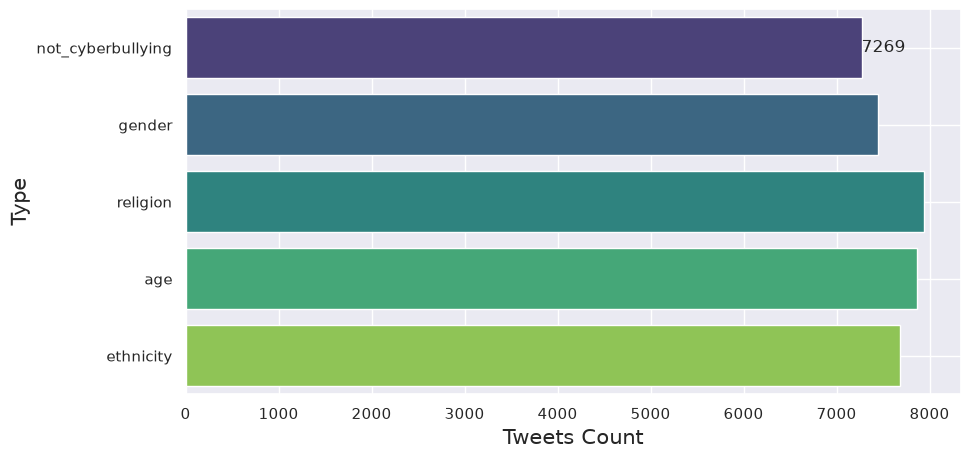

In [29]:
sns.set_theme()
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, y='cyberbullying_type', palette="viridis")
ax.bar_label(ax.containers[0])
plt.yticks(ticks=[0,1,2,3,4], labels=cyberbullying_type)
plt.xlabel('Tweets Count', size=15)
plt.ylabel('Type', size=15)
plt.grid(color='w')

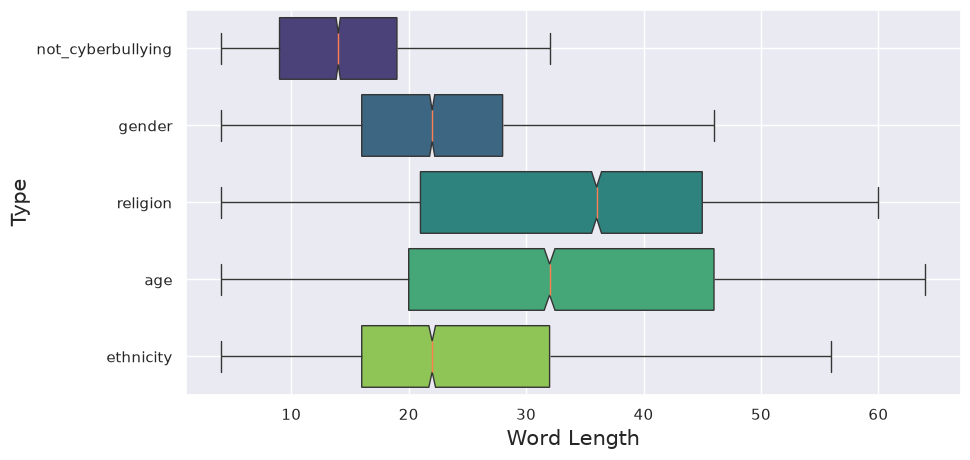

In [30]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, y='cyberbullying_type', x='word_count', orient='h', showfliers=False, palette='viridis', notch=True, medianprops={"color": "coral"})
plt.yticks(ticks=[0,1,2,3,4], labels=cyberbullying_type)
plt.xlabel('Word Length', size=15)
plt.ylabel('Type', size=15)
plt.grid(color='w')

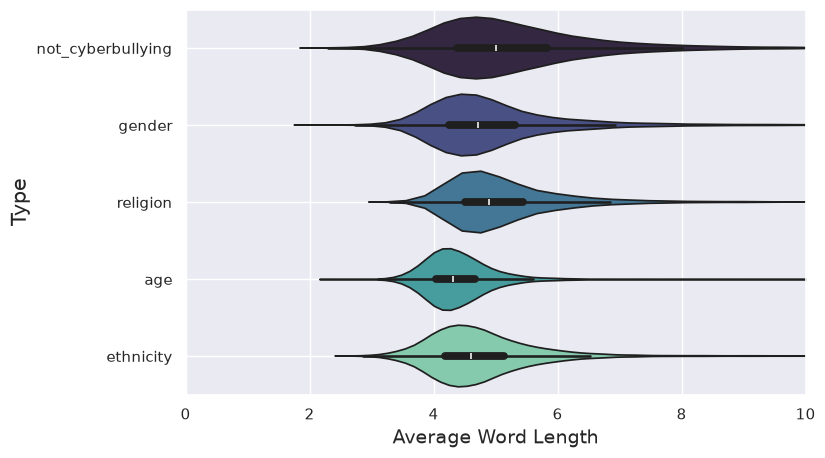

In [31]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, y='cyberbullying_type', x='avg_word_length', orient='h', palette='mako')
plt.xlim(0, 10)
plt.yticks(ticks=[0,1,2,3,4], labels=cyberbullying_type)
plt.xlabel('Average Word Length', size=14)
plt.ylabel('Type', size=15)
plt.grid(color='w')

Text(31.25, 0.5, 'Average Word Length')

<Figure size 800x500 with 0 Axes>

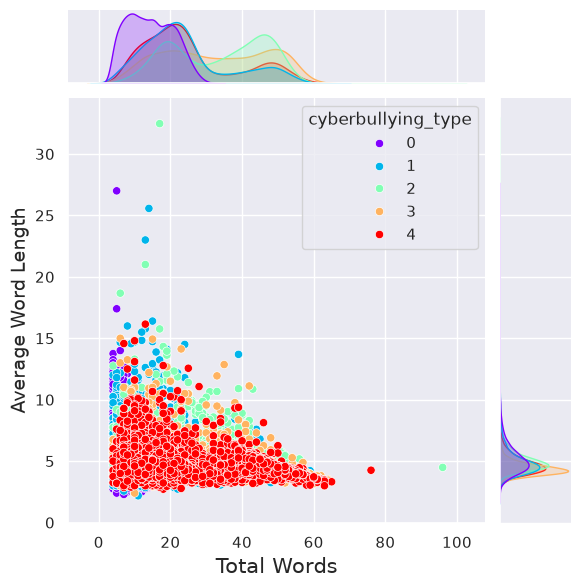

In [32]:
plt.figure(figsize=(8, 5))
sns.jointplot(data=df, y='avg_word_length', x='word_count', hue='cyberbullying_type', palette='rainbow')
plt.xlabel('Total Words', size=15)
plt.ylabel('Average Word Length', size=14)

### **Word Clouds**

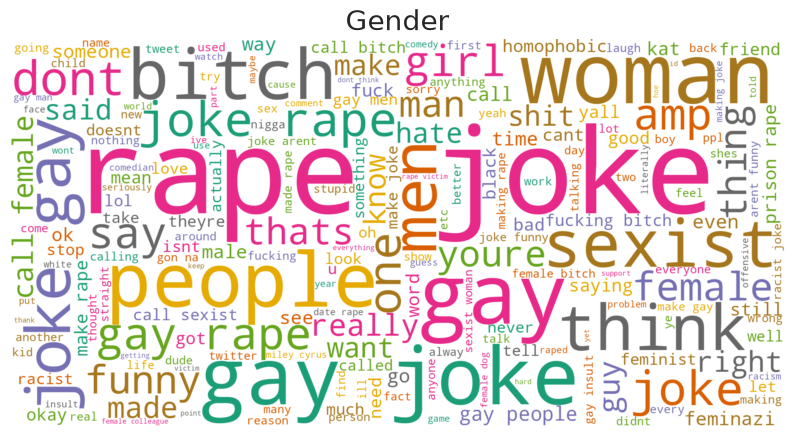

In [33]:
# Gender
plt.figure(figsize=(10, 10))
subset1 = df[df['cyberbullying_type']==1]
text_gender = subset1['clean_tweets'].values
wc1 = WordCloud(background_color='white', colormap='Dark2', width=2000, height=1000).generate(' '.join(text_gender))

plt.axis('off')
plt.title("Gender", fontsize=20)
plt.imshow(wc1, interpolation='bilinear')

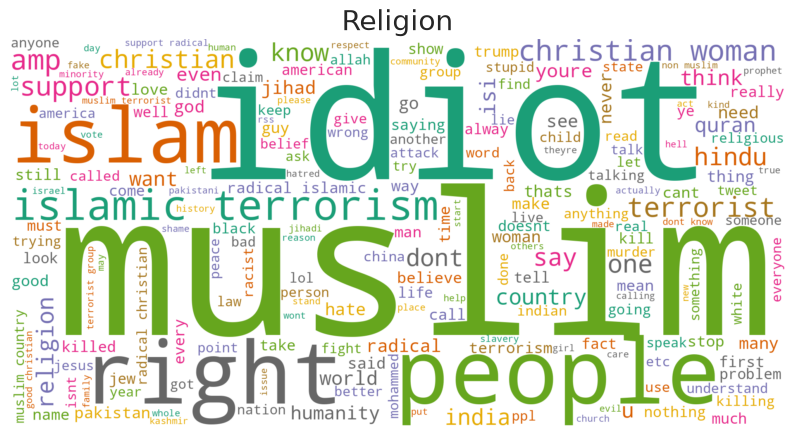

In [34]:
# Religion
plt.figure(figsize=(10, 10))
subset2 = df[df['cyberbullying_type']==2]
text_religion = subset2['clean_tweets'].values
wc2 = WordCloud(background_color='white', colormap='Dark2', width=2000, height=1000).generate(' '.join(text_religion))

plt.axis('off')
plt.title("Religion", fontsize=20)
plt.imshow(wc2, interpolation='bilinear')

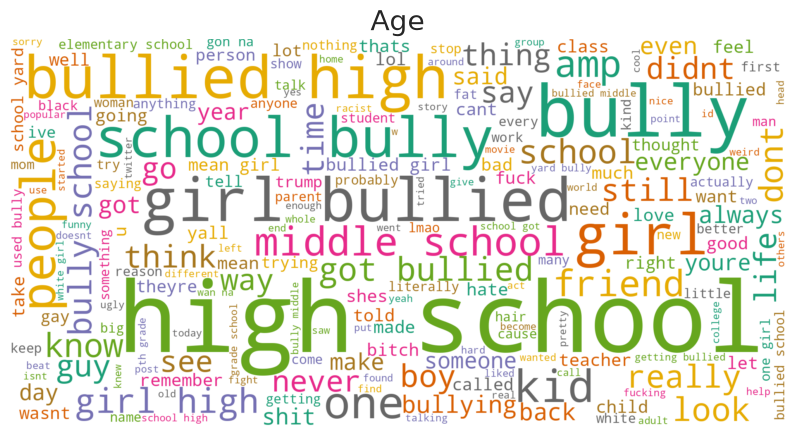

In [35]:
# Age
plt.figure(figsize=(10, 10))
subset3 = df[df['cyberbullying_type']==3]
text_age = subset3['clean_tweets'].values
wc3 = WordCloud(background_color='white', colormap='Dark2', width=2000, height=1000).generate(' '.join(text_age))

plt.axis('off')
plt.title("Age", fontsize=20)
plt.imshow(wc3, interpolation='bilinear')

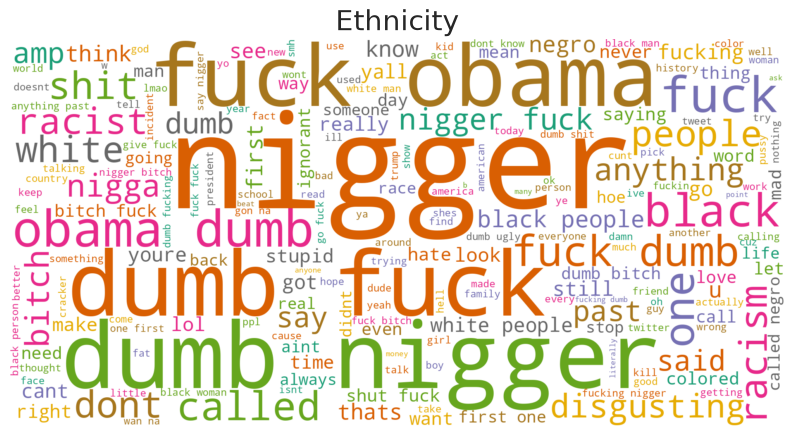

In [36]:
# Ethnicity
plt.figure(figsize=(10, 10))
subset4 = df[df['cyberbullying_type']==4]
text_ethnicity = subset4['clean_tweets'].values
wc4 = WordCloud(background_color='white', colormap='Dark2', width=2000, height=1000).generate(' '.join(text_ethnicity))

plt.axis('off')
plt.title("Ethnicity", fontsize=20)
plt.imshow(wc4, interpolation='bilinear')

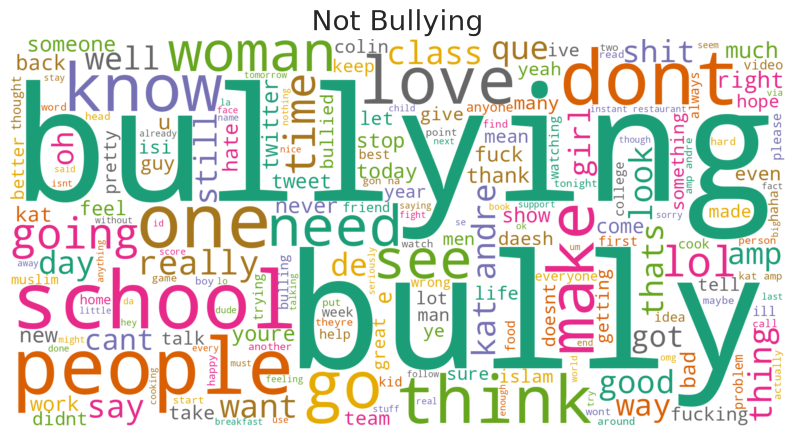

In [37]:
# Not Bullying
plt.figure(figsize=(10, 10))
subset0 = df[df['cyberbullying_type']==0]
text_not = subset0['clean_tweets'].values
wc0 = WordCloud(background_color='white', colormap='Dark2', width=2000, height=1000).generate(' '.join(text_not))

plt.axis('off')
plt.title("Not Bullying", fontsize=20)
plt.imshow(wc0, interpolation='bilinear')

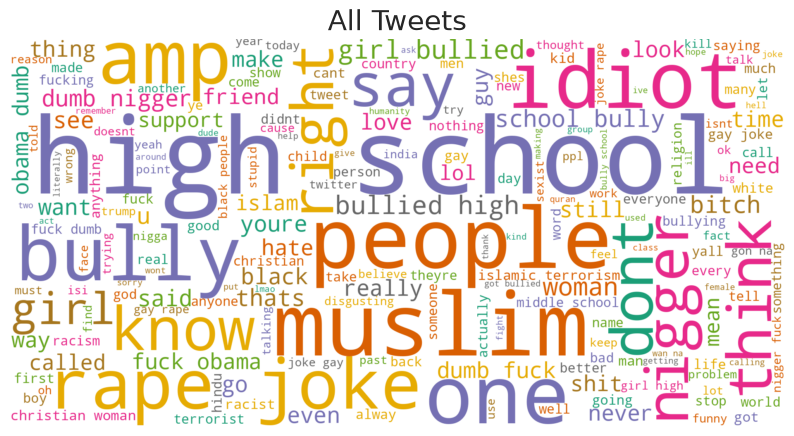

In [38]:
# All Tweets
plt.figure(figsize=(10, 10))
text_all = df['clean_tweets'].values
wc = WordCloud(background_color='white', colormap='Dark2', width=2000, height=1000).generate(' '.join(text_all))

plt.axis('off')
plt.title("All Tweets", fontsize=20)
plt.imshow(wc, interpolation='bilinear')

Checking which words are the most popular

In [39]:
from collections import Counter   # To count the frequency of each word

temp=[]
for tweet in df['clean_tweets']:
  for word in tweet.split():
    temp.append(word)
vocab = Counter(temp)
print("Vocabulary Size:", len(vocab))
print(list(vocab.items())[:5])

Vocabulary Size: 38477
[('word', 867), ('food', 128), ('crapilicious', 1), ('white', 2213), ('classy', 29)]


<br> Plotting

In [40]:
common_word=[]
freq=[]
for i, j in vocab.most_common()[:10]:
  common_word.append(i)
  freq.append(j)

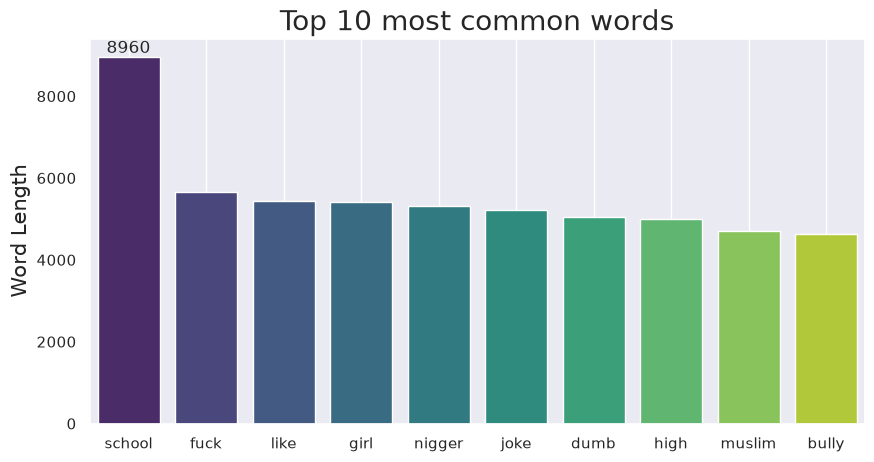

In [41]:
# Most common words
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=common_word, y=freq, palette='viridis')
plt.title('Top 10 most common words', size=20)
ax.bar_label(ax.containers[0])
plt.ylabel("Word Length", size=15)
plt.grid()

## ML Classifiers

Splitting the data into train and test

In [42]:
X = df['clean_tweets']
y = df['cyberbullying_type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=76)

**TF-IDF Vectorization**

In [ ]:
tfidf = TfidfVectorizer(ngram_range=(1,2))
tfidf.fit(X_train)    # Fit on train
print("No. of feature words:", len(tfidf.get_feature_names_out()))

joblib.dump(tfidf , "../models/tfidf.pkl")

No. of feature words: 291954


['tfidf.pkl']

In [44]:
X_train_tf = tfidf.transform(X_train)
X_test_tf = tfidf.transform(X_test)
print(f"{X_train_tf.shape = }\n{X_test_tf.shape = }")

X_train_tf.shape = (30561, 291954)
X_test_tf.shape = (7641, 291954)


Applying models

### ***Logistic Regression***

In [45]:
# Model training
lr = LogisticRegression(solver='saga', penalty='l2', random_state=394)
lr.fit(X_train_tf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",394
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'saga'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio

In [46]:
# Model prediction
y_pred_train = lr.predict(X_train_tf)
y_pred_test = lr.predict(X_test_tf)

Evaluating the model

In [47]:
# Model evaluation
print('\tClassification Report for Logistic Regression on Train\n\n', classification_report(y_train, y_pred_train, target_names=cyberbullying_type))
print('\n\tClassification Report for Logistic Regression on Test\n\n', classification_report(y_test, y_pred_test, target_names=cyberbullying_type))

	Classification Report for Logistic Regression on Train

                    precision    recall  f1-score   support

not_cyberbullying       0.88      0.95      0.91      5815
           gender       0.98      0.91      0.94      5958
         religion       0.98      0.98      0.98      6350
              age       0.98      0.99      0.98      6292
        ethnicity       0.99      0.99      0.99      6146

         accuracy                           0.96     30561
        macro avg       0.96      0.96      0.96     30561
     weighted avg       0.96      0.96      0.96     30561


	Classification Report for Logistic Regression on Test

                    precision    recall  f1-score   support

not_cyberbullying       0.80      0.79      0.80      1454
           gender       0.93      0.85      0.89      1490
         religion       0.95      0.95      0.95      1587
              age       0.92      0.99      0.95      1573
        ethnicity       0.96      0.99      0.97      

The performance scores have an overall accurcy of **92%**.<br>

Text(0.5, 1.0, 'Confusion Matrix LR')

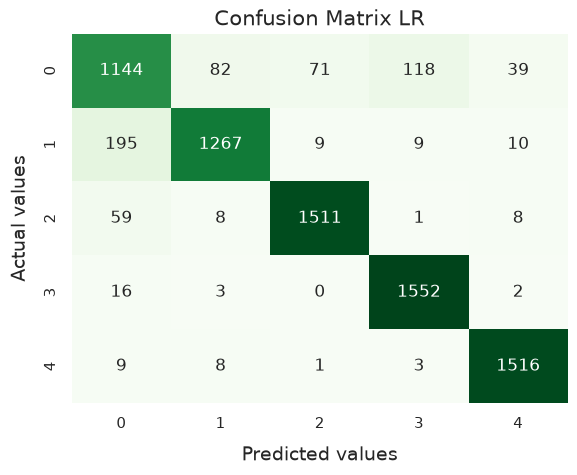

In [48]:
# Confusion Matrix for Logistic Regression
sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, cmap="Greens", fmt='', cbar=False)
plt.xlabel("Predicted values", fontdict = {'size':14}, labelpad = 10)
plt.ylabel("Actual values", fontdict = {'size':14}, labelpad = 10)
plt.title('Confusion Matrix LR', size=15)

### ***Naive-Bayes'***

In [49]:
# Model training
mnb = MultinomialNB(alpha=0.1)
mnb.fit(X_train_tf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.1
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](5,)","[5815.,5958.,6350.,6292.,6146.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](5,)","[-1.66,-1.63,-1.57,-1.58,-1.6 ]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](5,)","[0,1,2,3,4]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](5, 291954)","[[0. ,0. ,0. ,...,0.26,0. ,0. ], [0. ,0. ,0. ,...,0. ,0.34,0.34], [0. ,0. ,0. ,...,0. ,0. ,0. ], [0.45,0.3 ,0.17,...,0. ,0. ,0. ], [0. ,0. ,0. ,...,0. ,0. ,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](5, 291954)","[[-13.1 ,-13.1 ,-13.1 ,...,-11.82,-13.1 ,-13.1 ], [-13.23,-13.23,-13.23,...,-13.23,-11.74,-11.74], [-13.36,-13.36,-13.36,...,-13.36,-13.36,-13.36], [-11.63,-11.96,-12.33,...,-13.33,-13.33,-13.33], [-13.27,-13.27,-13.27,...,-13.27,-13.27,-13.27]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,291954


In [50]:
# Model prediction
y_pred_train = mnb.predict(X_train_tf)
y_pred_test = mnb.predict(X_test_tf)

In [51]:
# Model evaluation
print('\tClassification Report for Naive-Bayes\' on Train\n\n', classification_report(y_train, y_pred_train, target_names=cyberbullying_type))
print('\n\tClassification Report for Naive-Bayes\' on Test\n\n', classification_report(y_test, y_pred_test, target_names=cyberbullying_type))

	Classification Report for Naive-Bayes' on Train

                    precision    recall  f1-score   support

not_cyberbullying       1.00      0.97      0.98      5815
           gender       1.00      0.99      0.99      5958
         religion       0.99      1.00      0.99      6350
              age       0.99      1.00      0.99      6292
        ethnicity       0.99      1.00      1.00      6146

         accuracy                           0.99     30561
        macro avg       0.99      0.99      0.99     30561
     weighted avg       0.99      0.99      0.99     30561


	Classification Report for Naive-Bayes' on Test

                    precision    recall  f1-score   support

not_cyberbullying       0.89      0.47      0.61      1454
           gender       0.86      0.85      0.86      1490
         religion       0.84      0.97      0.90      1587
              age       0.79      0.98      0.87      1573
        ethnicity       0.89      0.93      0.91      1537

        

Text(0.5, 1.0, 'Confusion Matrix NB')

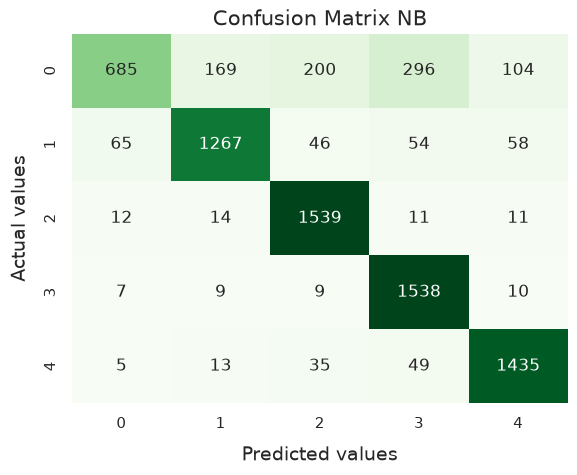

In [52]:
# Confusion Matrix for Naive-Bayes'
sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, cmap="Greens", fmt='', cbar=False)
plt.xlabel("Predicted values", fontdict = {'size':14}, labelpad = 10)
plt.ylabel("Actual values", fontdict = {'size':14}, labelpad = 10)
plt.title('Confusion Matrix NB', size=15)

### ***Random Forest***

In [53]:
# Model training
rf = RandomForestClassifier(n_estimators=100, criterion="entropy", max_depth=30, random_state=27)
rf.fit(X_train_tf, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",27
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootst

Applied hyperparameter tuning using GridSearchCV below to find the best parameters for our model.

In [54]:
from sklearn.model_selection import GridSearchCV

parameters = {'n_estimators': [50, 100],
              'criterion':['gini', 'entropy'],
              'max_depth': [10, 20],
              }

model = GridSearchCV(estimator=rf, param_grid=parameters)
model.fit(X_train_tf, y_train)
model.best_params_

{'criterion': 'entropy', 'max_depth': 20, 'n_estimators': 100}

In [55]:
# Model prediction
y_pred_train = rf.predict(X_train_tf)
y_pred_test = rf.predict(X_test_tf)

In [56]:
# Model evaluation
print('\tClassification Report for Random Forest on Train\n\n', classification_report(y_train, y_pred_train, target_names=cyberbullying_type))
print('\n\tClassification Report for Random Forest on Test\n\n', classification_report(y_test, y_pred_test, target_names=cyberbullying_type))

	Classification Report for Random Forest on Train

                    precision    recall  f1-score   support

not_cyberbullying       0.76      0.92      0.84      5815
           gender       0.98      0.77      0.86      5958
         religion       0.96      0.96      0.96      6350
              age       0.97      0.98      0.97      6292
        ethnicity       0.98      0.98      0.98      6146

         accuracy                           0.92     30561
        macro avg       0.93      0.92      0.92     30561
     weighted avg       0.93      0.92      0.92     30561


	Classification Report for Random Forest on Test

                    precision    recall  f1-score   support

not_cyberbullying       0.74      0.88      0.81      1454
           gender       0.97      0.76      0.85      1490
         religion       0.95      0.94      0.94      1587
              age       0.95      0.97      0.96      1573
        ethnicity       0.96      0.97      0.97      1537

      

It reduced the overfitting issue and gave an impressive accuracy of **90%** 

Text(0.5, 1.0, 'Confusion Matrix RF')

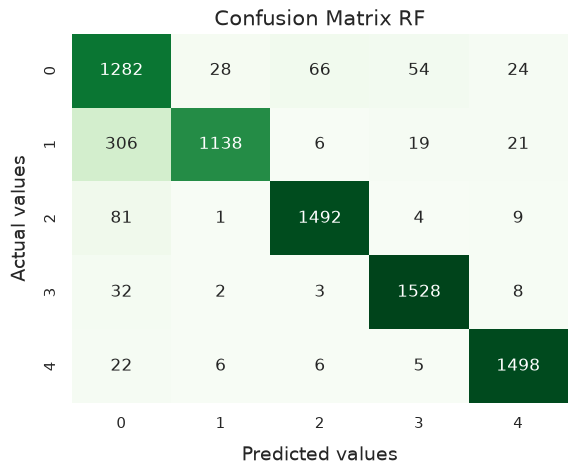

In [57]:
# Confusion Matrix for Random Forest
sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, cmap="Greens", fmt='', cbar=False)
plt.xlabel("Predicted values", fontdict = {'size':14}, labelpad = 10)
plt.ylabel("Actual values", fontdict = {'size':14}, labelpad = 10)
plt.title('Confusion Matrix RF', size=15)

**Ensemble**

Using Voting technique to aggregate the predictions to improve the performance of the model

In [58]:
# Model Training
from sklearn.ensemble import VotingClassifier

vot = VotingClassifier(estimators = [('lr', lr), ('mnb', mnb), ('rf', rf)], voting='soft')
vot.fit(X_train_tf, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('mnb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](5,)","[0,1,2,3,4]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[LogisticRegre...solver='saga'), MultinomialNB(alpha=0.1), RandomForestC...ndom_state=27)]"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying classifier exposes such an attribute when fit... versionadded:: 0.24,int,291954


In [59]:
# Model prediction
y_pred_train = vot.predict(X_train_tf)
y_pred_test = vot.predict(X_test_tf)

In [60]:
# Model evaluation
print('\tClassification Report for Voting on Train\n\n', classification_report(y_train, y_pred_train, target_names=cyberbullying_type))
print('\n\tClassification Report for Voting on Test\n\n', classification_report(y_test, y_pred_test, target_names=cyberbullying_type))

	Classification Report for Voting on Train

                    precision    recall  f1-score   support

not_cyberbullying       0.99      0.98      0.98      5815
           gender       1.00      0.99      0.99      5958
         religion       0.99      1.00      0.99      6350
              age       0.99      1.00      0.99      6292
        ethnicity       1.00      1.00      1.00      6146

         accuracy                           0.99     30561
        macro avg       0.99      0.99      0.99     30561
     weighted avg       0.99      0.99      0.99     30561


	Classification Report for Voting on Test

                    precision    recall  f1-score   support

not_cyberbullying       0.86      0.70      0.77      1454
           gender       0.91      0.86      0.89      1490
         religion       0.91      0.98      0.94      1587
              age       0.89      0.99      0.94      1573
        ethnicity       0.95      0.98      0.96      1537

         accuracy   

Text(0.5, 1.0, 'Confusion Matrix Voting')

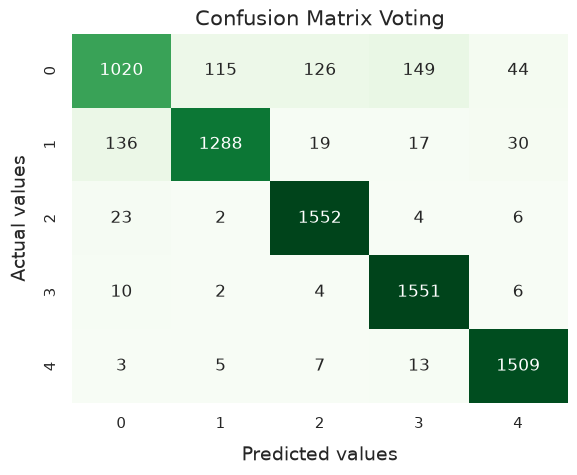

In [61]:
# Confusion Matrix after Voting
sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, cmap="Greens", fmt='', cbar=False)
plt.xlabel("Predicted values", fontdict = {'size':14}, labelpad = 10)
plt.ylabel("Actual values", fontdict = {'size':14}, labelpad = 10)
plt.title('Confusion Matrix Voting', size=15)

## Model Saving, Loading and Prediction

In [ ]:
# Saving Logistic Regression Model
model_file = open('LogisticRegression.pickle','wb')
pickle.dump(lr, model_file)
model_file.close()

# Saving Naive-Bayes' Model
model_file = open('NaiveBayes.pickle','wb')
pickle.dump(mnb, model_file)
model_file.close()

# Saving Random Forest Model
model_file = open('RandomForest.pickle','wb')
pickle.dump(rf, model_file)
model_file.close()



joblib.dump(vot , "../models/Voting.pkl")

['Voting.pkl']

### **Prediction using saved model**

In [63]:
# Defing our custom prediction function
def predict(model, texts):
    clean_texts = [pre_processing_custom(text) for text in texts]
    text_data = tfidf.transform(clean_texts)
    prediction = model.predict(text_data)

    data = []
    for text, prediction in zip(texts, prediction):
        data.append((text, prediction))

    df = pd.DataFrame(data, columns = ['text','type'])
    df = df.replace([0,1,2,3,4], cyberbullying_type)
    return df

### **Prediction**

In [67]:
# Using our best model
model = joblib.load("../models/Voting.pkl")

# Providing some random toxic texts
texts = ["I hate you bitch",
        "School shooting. Haha dead.",
        "Treat them like black slaves",
        "I don't feel so good Mr. Potter",
        "christians are the worst"
        ]

#Our final prediction
predict(model, texts)

,text,type
0,I hate you bitch,gender
1,School shooting. Haha dead.,age
2,Treat them like black slaves,ethnicity
3,I don't feel so good Mr. Potter,not_cyberbullying
4,christians are the worst,religion
